In [67]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from pathlib import Path
import mcstasscript as ms
from scipy.optimize import curve_fit  

Total parsed monitors: 112
Active monitors (total > 0): 6

Top 10 matches to 4pi reference:
 1. ExitE3b.dat              type=2d total=1.735e+08 score=0.9656 corr=0.9629 cos=0.9685
 2. ExitE2.dat               type=2d total=3.57e+08 score=0.7556 corr=0.7083 cos=0.7591
 3. ExitC1.dat               type=2d total=2.507e+08 score=0.7523 corr=0.7046 cos=0.7561
 4. EndOfInsertPSD.dat       type=2d total=4.419e+08 score=0.6067 corr=0.5226 cos=0.6180
 5. startOfGuide.dat         type=2d total=8.185e+08 score=0.5999 corr=0.5138 cos=0.6117
 6. ExitE3a.dat              type=2d total=2.459e+08 score=0.5487 corr=0.4491 cos=0.5649


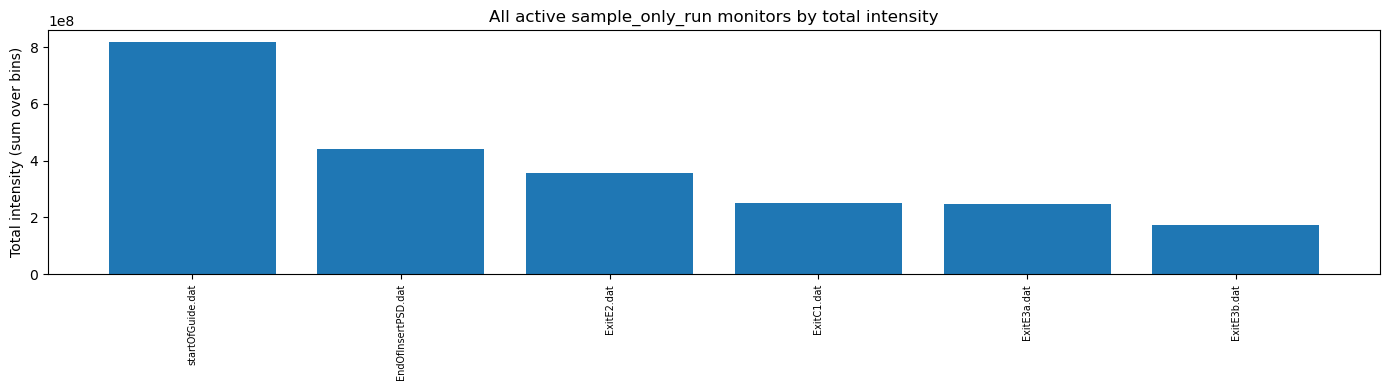

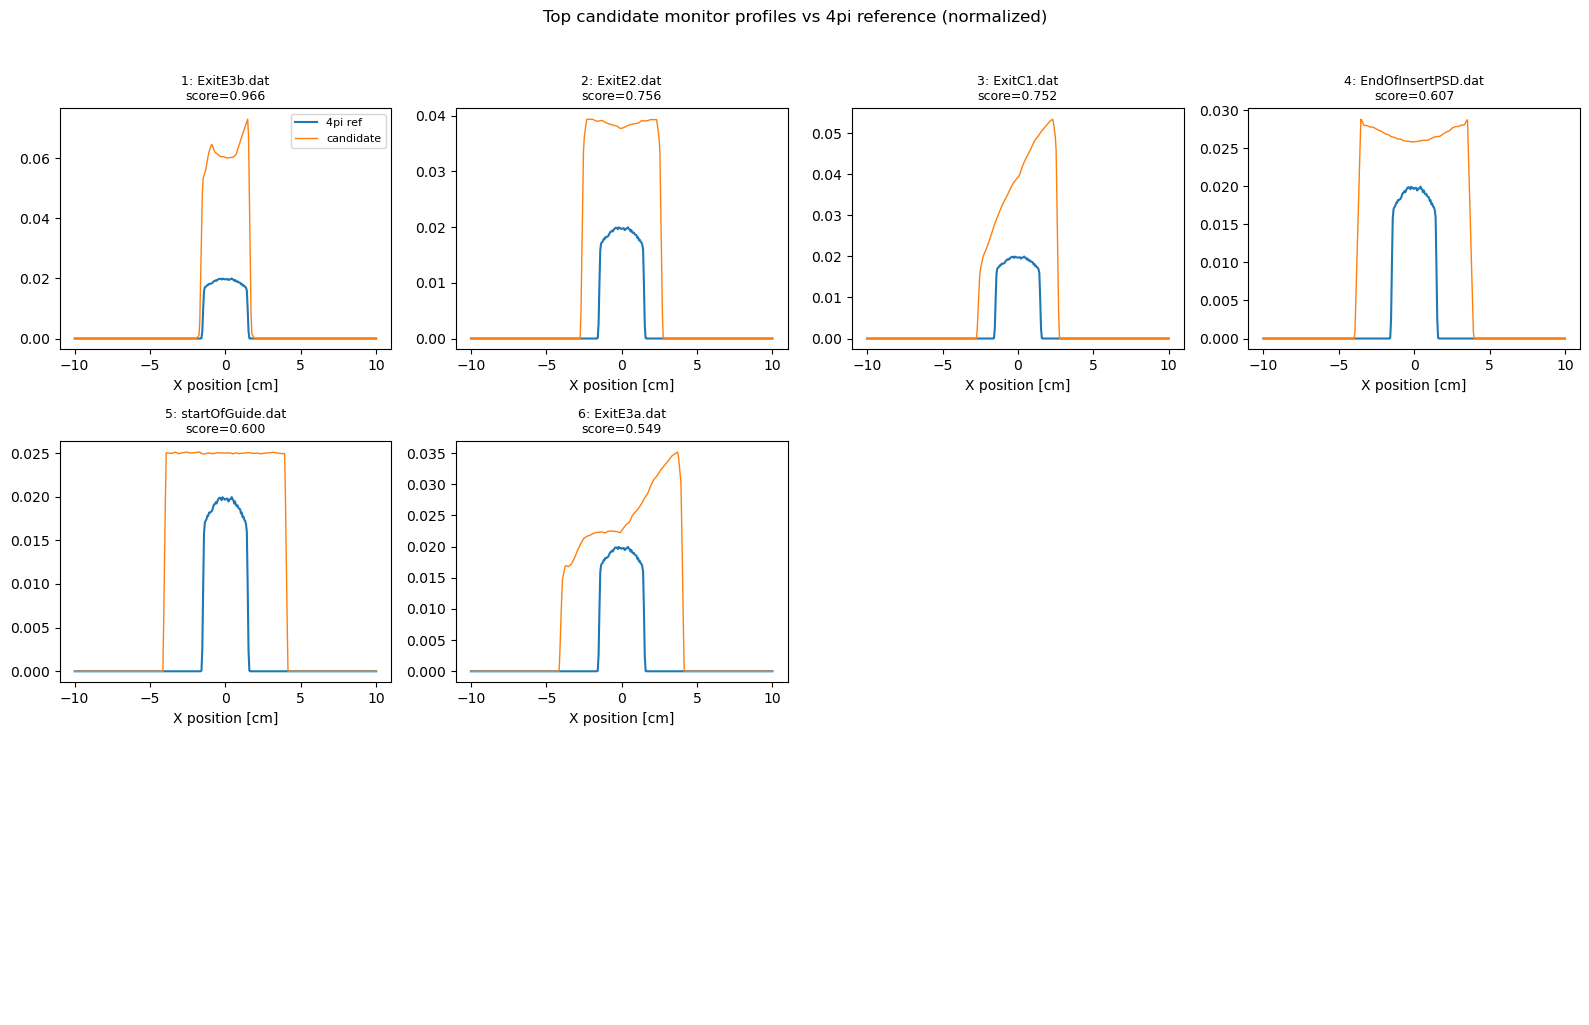

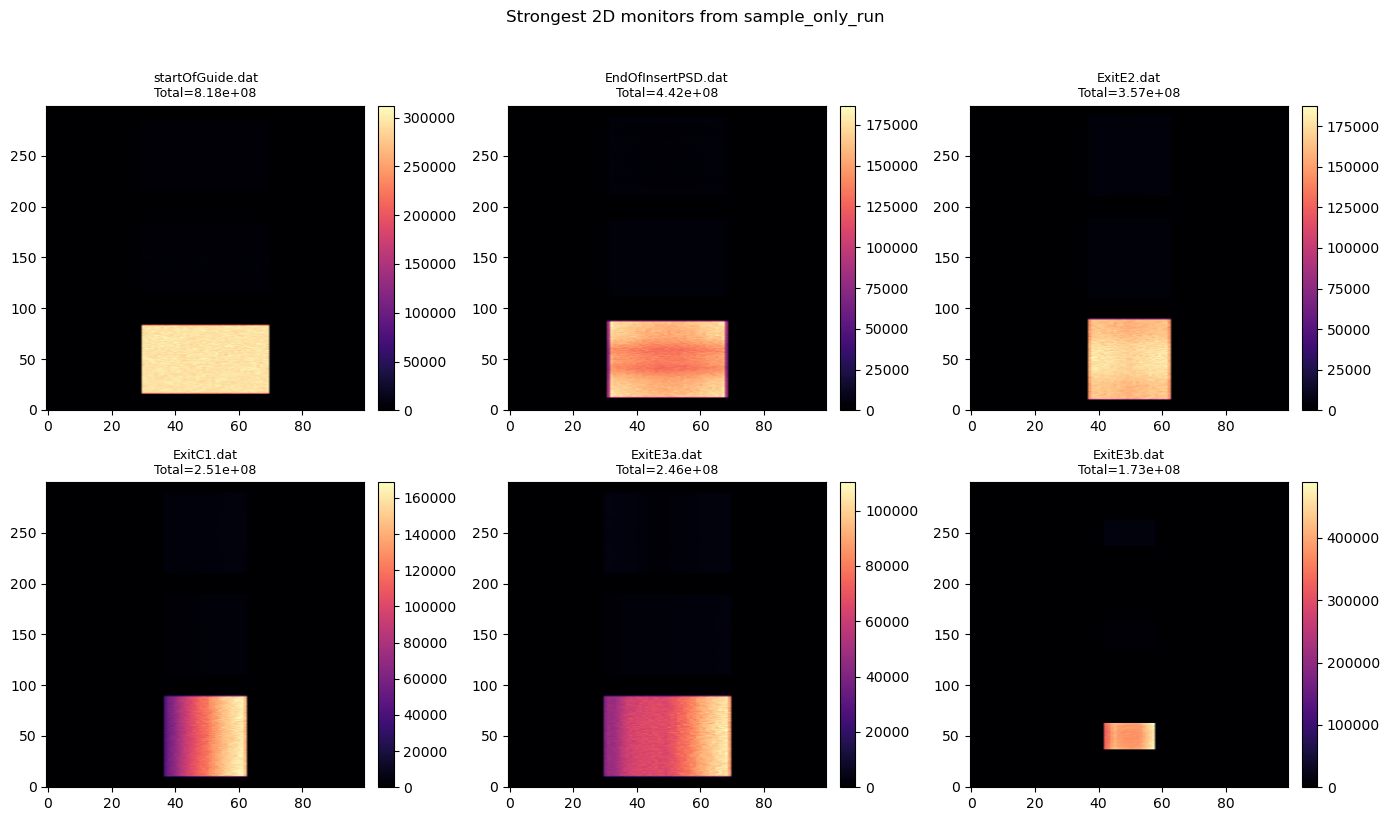


Best match candidate: ExitE3b.dat


In [68]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- Paths ---
workspace_root = Path('/Users/christian/Documents/Study/bachelor_project')
run_dir = workspace_root / 'geometry_optimization' / 'CAMEA_instrument' / 'sample_only_run'
reference_csv = workspace_root / 'mcmini' / '4pi_srcsimple.csv'

# --- Helpers ---
def parse_mccode_monitor(path: Path):
    """Parse McCode 1D/2D monitor files and return dict with type, data, and metadata."""
    lines = path.read_text(errors='ignore').splitlines()
    monitor_type = None
    xlimits = None
    xylimits = None
    xlabel = None
    ylabel = None

    for line in lines:
        if line.startswith('# type:'):
            monitor_type = line.split(':', 1)[1].strip()
        elif line.startswith('# xlimits:'):
            vals = line.split(':', 1)[1].strip().split()
            if len(vals) >= 2:
                xlimits = (float(vals[0]), float(vals[1]))
        elif line.startswith('# xylimits:'):
            vals = line.split(':', 1)[1].strip().split()
            if len(vals) >= 4:
                xylimits = tuple(float(v) for v in vals[:4])
        elif line.startswith('# xlabel:'):
            xlabel = line.split(':',1)[1].strip()
        elif line.startswith('# ylabel:'):
            ylabel = line.split(':',1)[1].strip()

    data_start = None
    for i, line in enumerate(lines):
        if line.startswith('# Data ') and ' I:' in line:
            data_start = i + 1
            break

    if data_start is None:
        raise ValueError(f'Could not find data section in {path.name}')

    rows = []
    for line in lines[data_start:]:
        s = line.strip()
        if not s or s.startswith('#'):
            continue
        try:
            row = [float(x) for x in s.split()]
            rows.append(row)
        except ValueError:
            continue

    if not rows:
        raise ValueError(f'No numeric data found in {path.name}')

    if monitor_type and monitor_type.startswith('array_1d'):
        arr = np.array(rows, dtype=float)
        if arr.ndim == 2 and arr.shape[1] >= 2:
            x = arr[:, 0]
            intensity = arr[:, 1]
        else:
            x = np.arange(len(arr), dtype=float)
            intensity = np.asarray(arr).reshape(-1)
        return {
            'path': path,
            'type': '1d',
            'x': x,
            'I': intensity,
            'xlimits': xlimits,
            'xlabel': xlabel,
            'ylabel': ylabel,
            'total': float(np.sum(intensity)),
        }

    matrix = np.array(rows, dtype=float)
    if matrix.ndim == 1:
        matrix = matrix[np.newaxis, :]

    return {
        'path': path,
        'type': '2d',
        'I2d': matrix,
        'xylimits': xylimits,
        'xlabel': xlabel,
        'ylabel': ylabel,
        'total': float(np.sum(matrix)),
    }


def load_4pi_reference_profile(csv_path: Path):
    """
    Load 4pi binned monitor CSV (ix,iy,I) and collapse to a 1D profile in ix.
    Returns normalized profile of length nx.
    """
    ix = []
    iy = []
    I = []
    with csv_path.open('r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith('#'):
                continue
            parts = s.split(',')
            if len(parts) < 3:
                continue
            try:
                ix.append(int(parts[0]))
                iy.append(int(parts[1]))
                I.append(float(parts[2]))
            except ValueError:
                continue

    if not I:
        raise ValueError(f'No valid data rows in {csv_path}')

    ix = np.array(ix)
    iy = np.array(iy)
    I = np.array(I, dtype=float)

    nx = int(ix.max()) + 1
    ny = int(iy.max()) + 1
    grid = np.zeros((ny, nx), dtype=float)
    grid[iy, ix] = I

    profile = np.sum(grid, axis=0)
    s = profile.sum()
    if s > 0:
        profile = profile / s
    return profile


def to_profile(record):
    """Convert a parsed monitor record to a 1D profile suitable for shape comparison."""
    if record['type'] == '1d':
        p = np.asarray(record['I'], dtype=float)
    else:
        p = np.sum(np.asarray(record['I2d'], dtype=float), axis=0)

    p = np.clip(p, 0, None)
    s = p.sum()
    if s > 0:
        p = p / s
    return p


def resample_profile(profile, n=360):
    x_old = np.linspace(0.0, 1.0, len(profile))
    x_new = np.linspace(0.0, 1.0, n)
    return np.interp(x_new, x_old, profile)


def score_similarity(p, ref):
    """
    Combined score favoring shape agreement.
    corr in [-1,1], cosine in [0,1], mse_norm in [0,1] after clipping.
    """
    if np.allclose(p, 0) or np.allclose(ref, 0):
        return {'corr': -1.0, 'cosine': 0.0, 'mse': 1.0, 'score': -1.0}

    p2 = p - p.mean()
    r2 = ref - ref.mean()
    denom = np.linalg.norm(p2) * np.linalg.norm(r2)
    corr = float(np.dot(p2, r2) / denom) if denom > 0 else -1.0

    denom2 = np.linalg.norm(p) * np.linalg.norm(ref)
    cosine = float(np.dot(p, ref) / denom2) if denom2 > 0 else 0.0

    mse = float(np.mean((p - ref) ** 2))
    mse_norm = max(0.0, min(1.0, 1.0 - mse / 0.01))

    score = 0.5 * corr + 0.4 * cosine + 0.1 * mse_norm
    return {'corr': corr, 'cosine': cosine, 'mse': mse, 'score': score}


# --- Load run data ---
monitor_files = sorted(list(run_dir.glob('*.psd')) + list(run_dir.glob('*.dat')))
records = []
for p in monitor_files:
    try:
        records.append(parse_mccode_monitor(p))
    except Exception as e:
        print(f'Skipped {p.name}: {e}')

if not records:
    raise RuntimeError(f'No parseable monitor files found in {run_dir}')

# --- Load 4pi reference and score all monitors ---
ref_profile = load_4pi_reference_profile(reference_csv)
ref_rs = resample_profile(ref_profile, 360)

scored = []
for r in records:
    prof = to_profile(r)
    prof_rs = resample_profile(prof, 360)
    sim = score_similarity(prof_rs, ref_rs)
    scored.append({
        'name': r['path'].name,
        'type': r['type'],
        'total': r['total'],
        'profile': prof_rs,
        **sim,
    })

# Keep monitors that actually saw intensity
active = [s for s in scored if s['total'] > 0]
active_sorted = sorted(active, key=lambda x: x['score'], reverse=True)

print(f'Total parsed monitors: {len(records)}')
print(f'Active monitors (total > 0): {len(active)}')
print('\nTop 10 matches to 4pi reference:')
for i, s in enumerate(active_sorted[:10], 1):
    print(f"{i:2d}. {s['name']:<24} type={s['type']} total={s['total']:.4g} "
          f"score={s['score']:.4f} corr={s['corr']:.4f} cos={s['cosine']:.4f}")

# --- Plot 1: total intensity per active monitor ---
plt.figure(figsize=(14, 4))
names = [s['name'] for s in active]
totals = np.array([s['total'] for s in active], dtype=float)
order = np.argsort(totals)[::-1]
plt.bar(np.arange(len(order)), totals[order])
plt.xticks(np.arange(len(order)), [names[i] for i in order], rotation=90, fontsize=7)
plt.ylabel('Total intensity (sum over bins)')
plt.title('All active sample_only_run monitors by total intensity')
plt.tight_layout()
plt.show()

# --- Plot 2: top matches vs 4pi reference ---
n_show = min(12, len(active_sorted))
if n_show > 0:
    fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=False, sharey=False)
    axes = axes.ravel()

    def make_x_for_record(rec, n):
        # produce an x axis of length n in physical units when possible
        if rec is None:
            return np.linspace(0, n-1, n)
        if rec['type'] == '1d':
            if 'x' in rec and rec['x'] is not None and len(rec['x']) > 1:
                xmin, xmax = float(np.min(rec['x'])), float(np.max(rec['x']))
                return np.linspace(xmin, xmax, n)
            if rec.get('xlimits') is not None:
                xmin, xmax = rec['xlimits']
                return np.linspace(xmin, xmax, n)
        if rec['type'] == '2d' and rec.get('xylimits') is not None:
            xmin, xmax, ymin, ymax = rec['xylimits']
            return np.linspace(xmin, xmax, n)
        # fallback to index axis
        return np.linspace(0, n-1, n)

    for i in range(12):
        ax = axes[i]
        if i < n_show:
            s = active_sorted[i]
            # find original record
            rec = next((r for r in records if r['path'].name == s['name']), None)
            nlen = len(s['profile'])
            x = make_x_for_record(rec, nlen)
            # resample reference to same physical axis length for visual comparison
            ref_x = np.linspace(x.min(), x.max(), len(ref_rs))
            ax.plot(ref_x, ref_rs, label='4pi ref', lw=1.5)
            ax.plot(x, s['profile'], label='candidate', lw=1.0)
            xlabel = rec.get('xlabel') if rec is not None and rec.get('xlabel') else 'X'
            ax.set_xlabel(xlabel)
            ax.set_title(f"{i+1}: {s['name']}\nscore={s['score']:.3f}", fontsize=9)
        else:
            ax.axis('off')

    axes[0].legend(fontsize=8)
    fig.suptitle('Top candidate monitor profiles vs 4pi reference (normalized)', y=1.02)
    fig.tight_layout()
    plt.show()

# --- Plot 3: quick gallery of strongest 2D monitors ---
active_2d = [r for r in records if r['type'] == '2d' and r['total'] > 0]
active_2d = sorted(active_2d, key=lambda r: r['total'], reverse=True)

n2 = min(6, len(active_2d))
if n2 > 0:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    for i in range(6):
        ax = axes[i]
        if i < n2:
            r = active_2d[i]
            im = ax.imshow(r['I2d'], origin='lower', aspect='auto', cmap='magma')
            ax.set_title(f"{r['path'].name}\nTotal={r['total']:.3g}", fontsize=9)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            ax.axis('off')

    fig.suptitle('Strongest 2D monitors from sample_only_run', y=1.02)
    fig.tight_layout()
    plt.show()

best = active_sorted[0]['name'] if active_sorted else None
print('\nBest match candidate:', best)

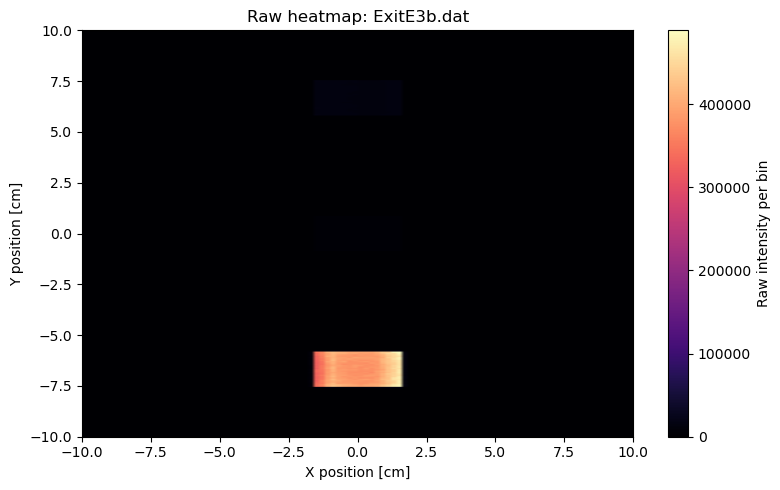

Shape: (300, 100), total intensity: 1.73471e+08


In [69]:
# Raw heatmap for ExitE3b.dat (no normalization)
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

base = Path('/Users/christian/Documents/Study/bachelor_project')
exit_file = base / 'geometry_optimization' / 'CAMEA_instrument' / 'sample_only_run' / 'ExitE3b.dat'

lines = exit_file.read_text(errors='ignore').splitlines()

xylimits = None
data_start = None
for i, line in enumerate(lines):
    if line.startswith('# xylimits:'):
        vals = line.split(':', 1)[1].strip().split()
        if len(vals) >= 4:
            xylimits = tuple(float(v) for v in vals[:4])
    if line.startswith('# Data ') and ' I:' in line:
        data_start = i + 1
        break

if data_start is None:
    raise ValueError('Could not find data section in ExitE3b.dat')

rows = []
for line in lines[data_start:]:
    s = line.strip()
    if not s or s.startswith('#'):
        continue
    rows.append([float(x) for x in s.split()])

I2d = np.array(rows, dtype=float)

plt.figure(figsize=(8, 5))
if xylimits is not None:
    extent = [xylimits[0], xylimits[1], xylimits[2], xylimits[3]]
    im = plt.imshow(I2d, origin='lower', aspect='auto', cmap='magma', extent=extent)
    plt.xlabel('X position [cm]')
    plt.ylabel('Y position [cm]')
else:
    im = plt.imshow(I2d, origin='lower', aspect='auto', cmap='magma')
    plt.xlabel('X bin')
    plt.ylabel('Y bin')

plt.title('Raw heatmap: ExitE3b.dat')
plt.colorbar(im, label='Raw intensity per bin')
plt.tight_layout()
plt.show()

print(f'Shape: {I2d.shape}, total intensity: {I2d.sum():.6g}')

Found 8 .dat files and 104 .psd files in /Users/christian/Documents/Study/bachelor_project/geometry_optimization/CAMEA_instrument/sample_only_run


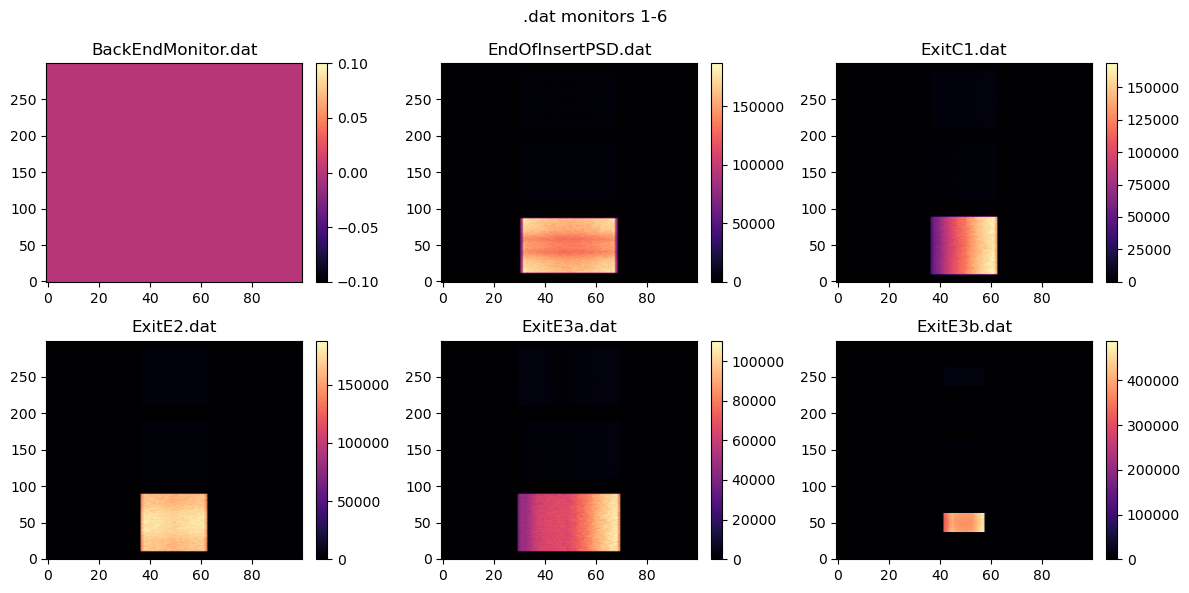

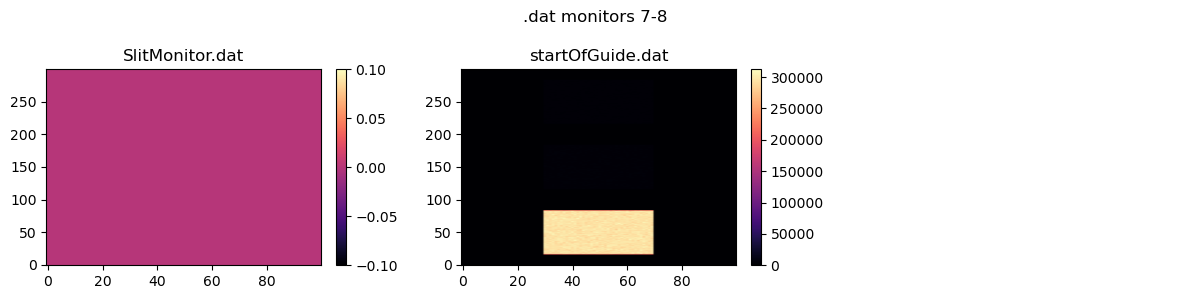

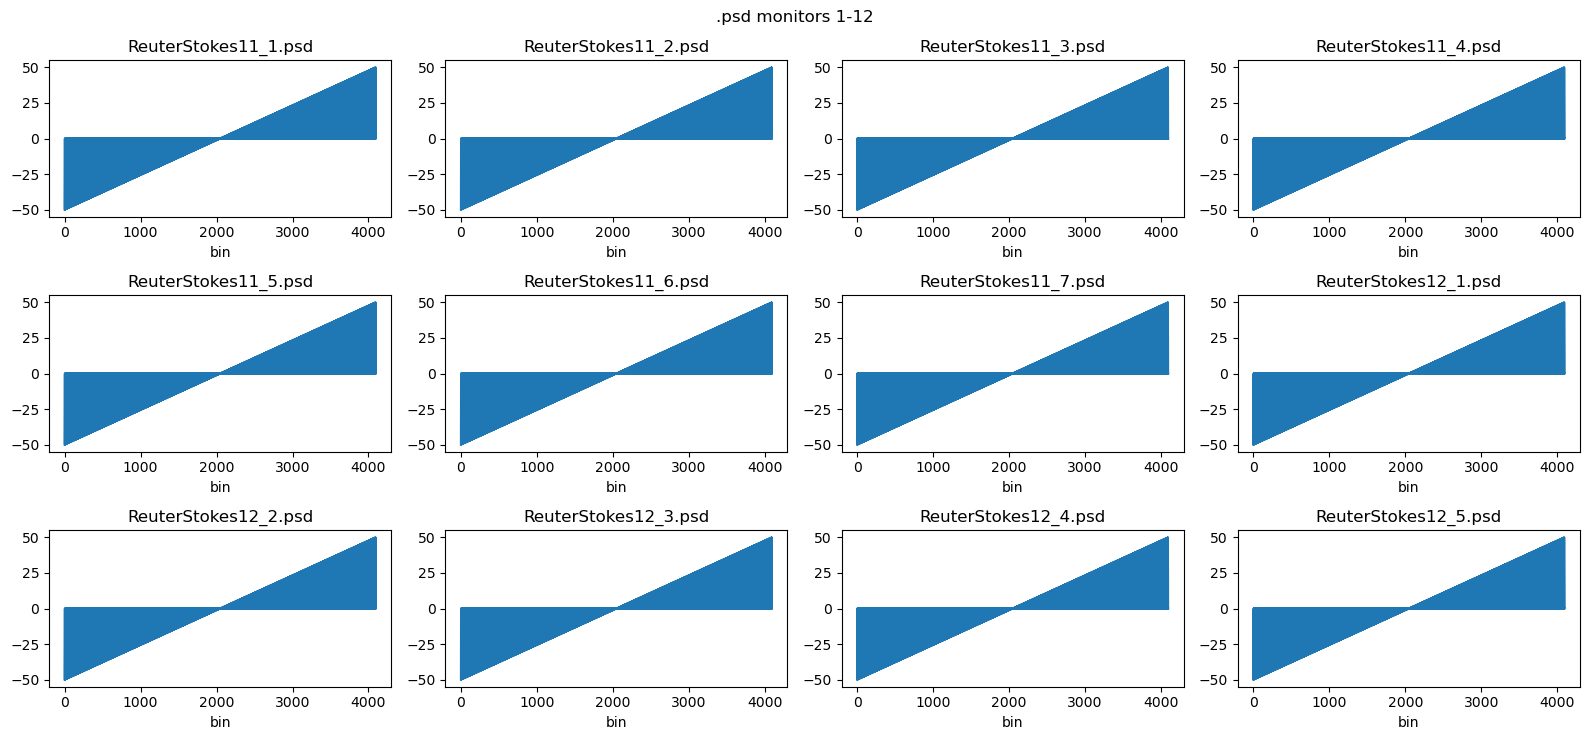

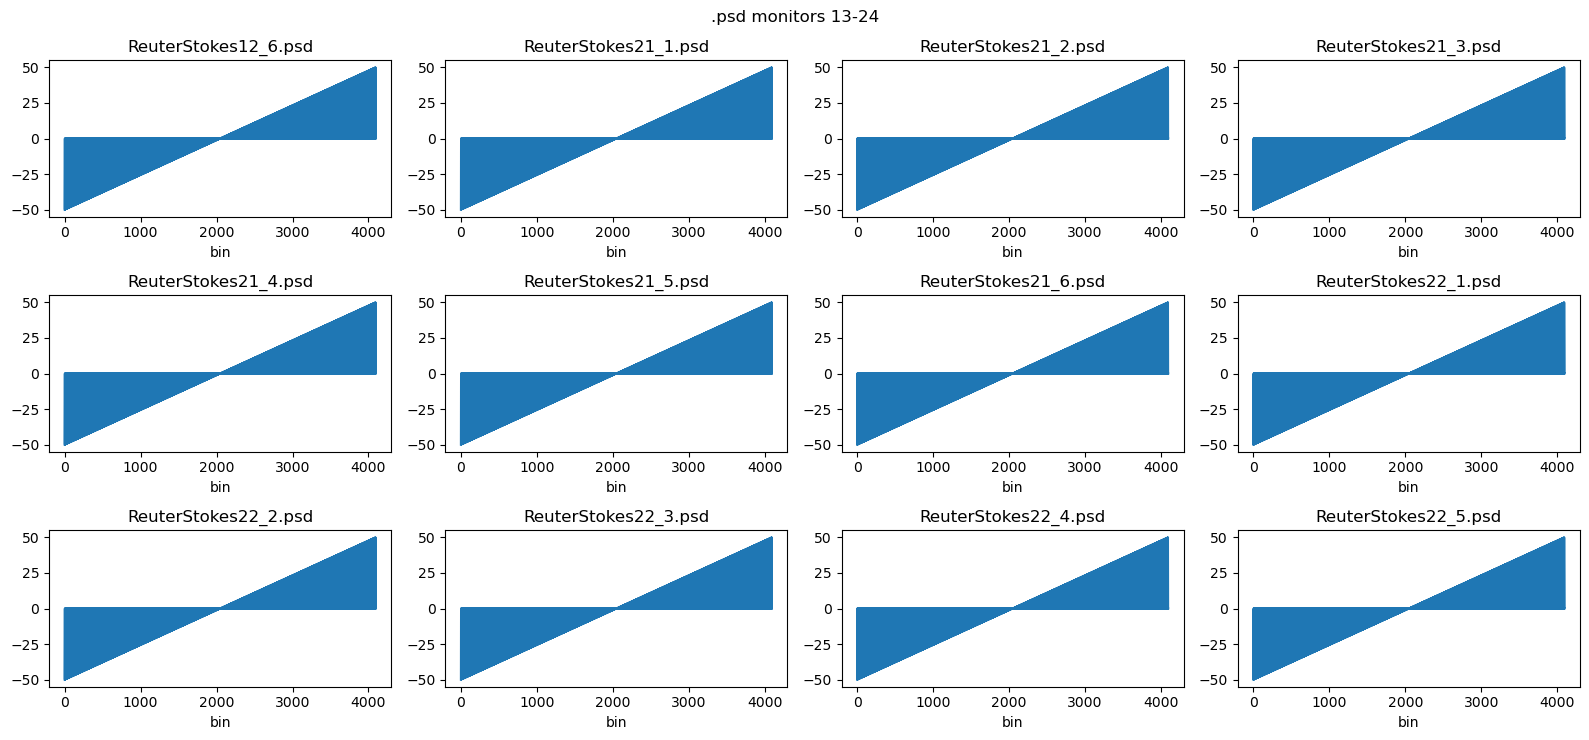

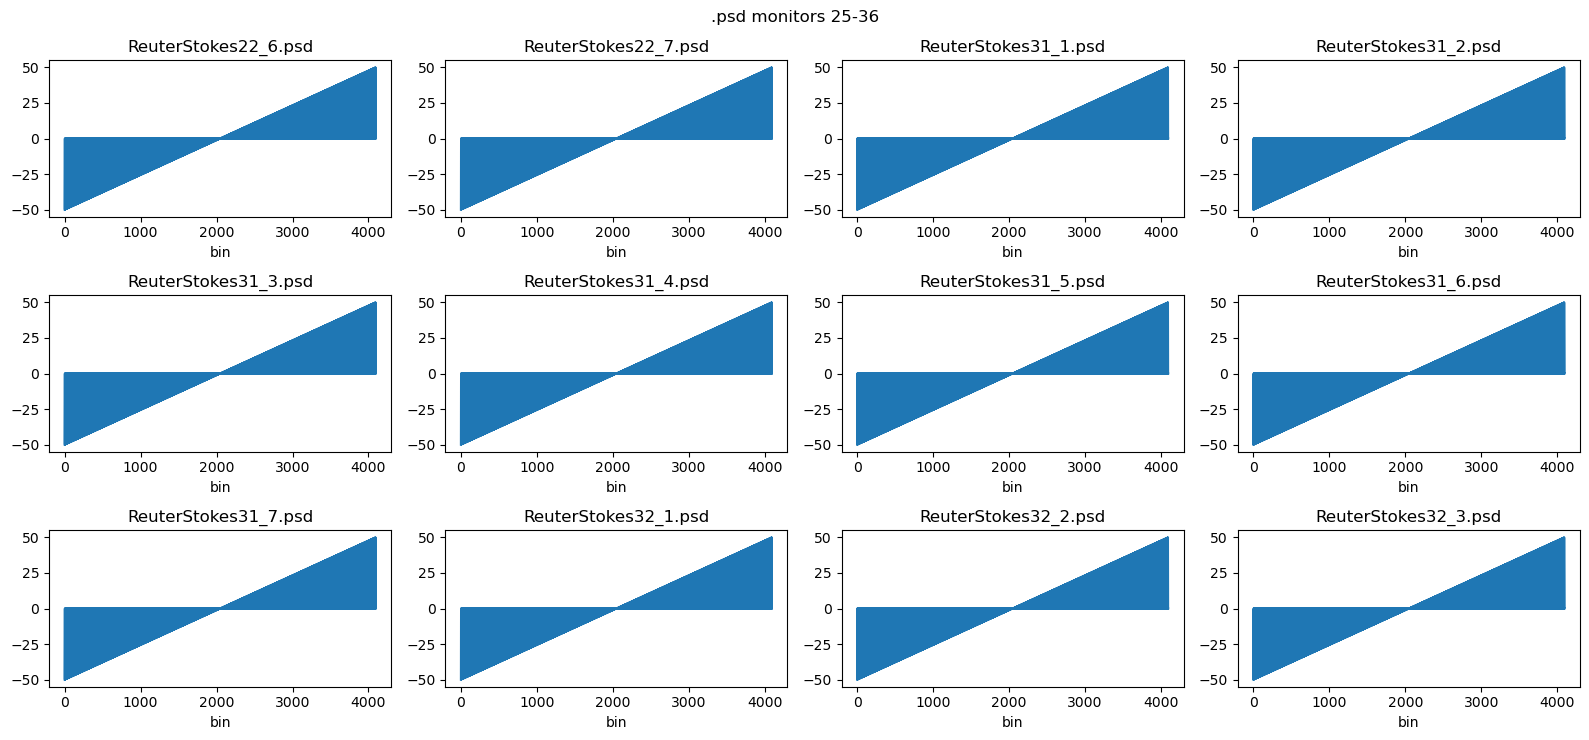

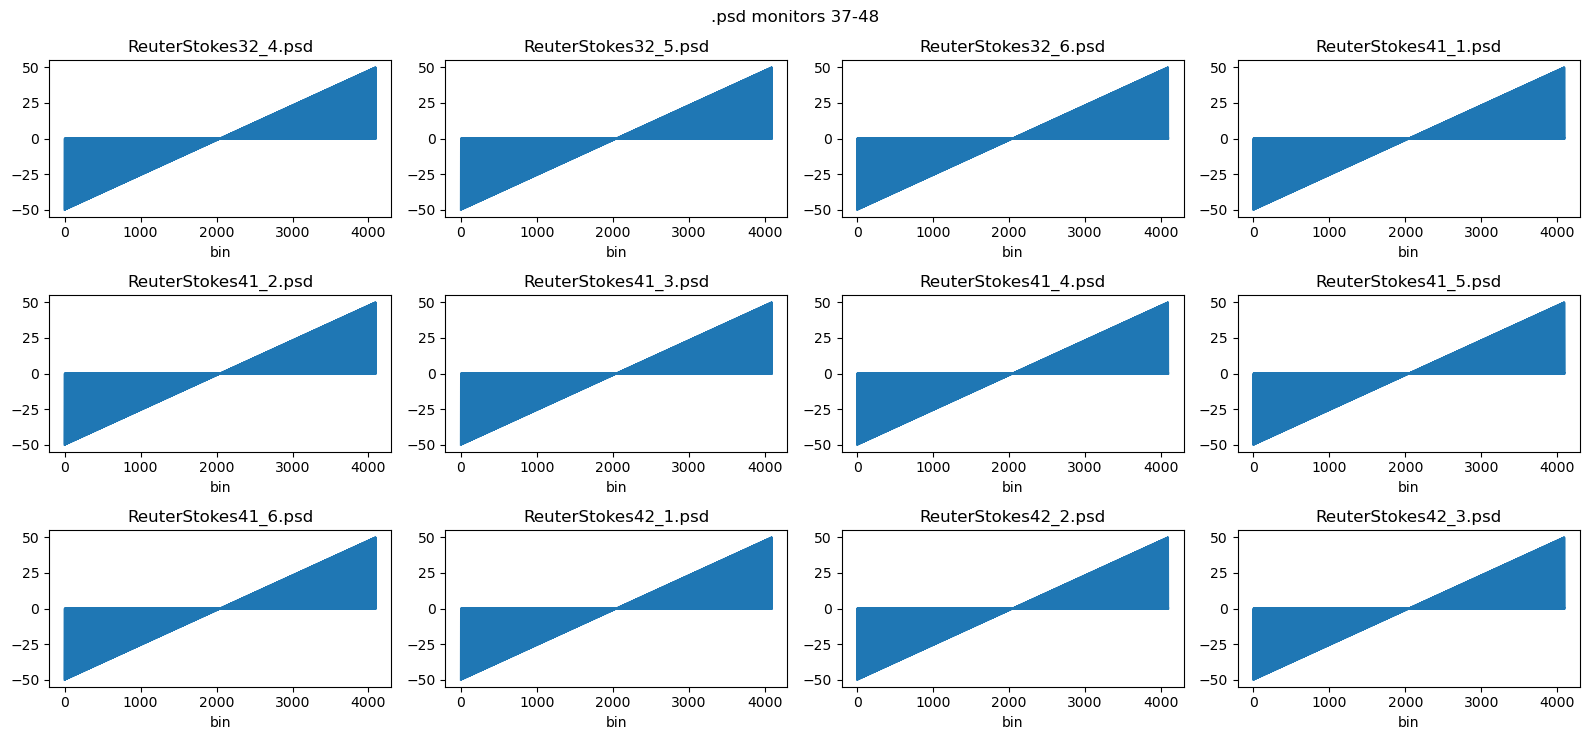

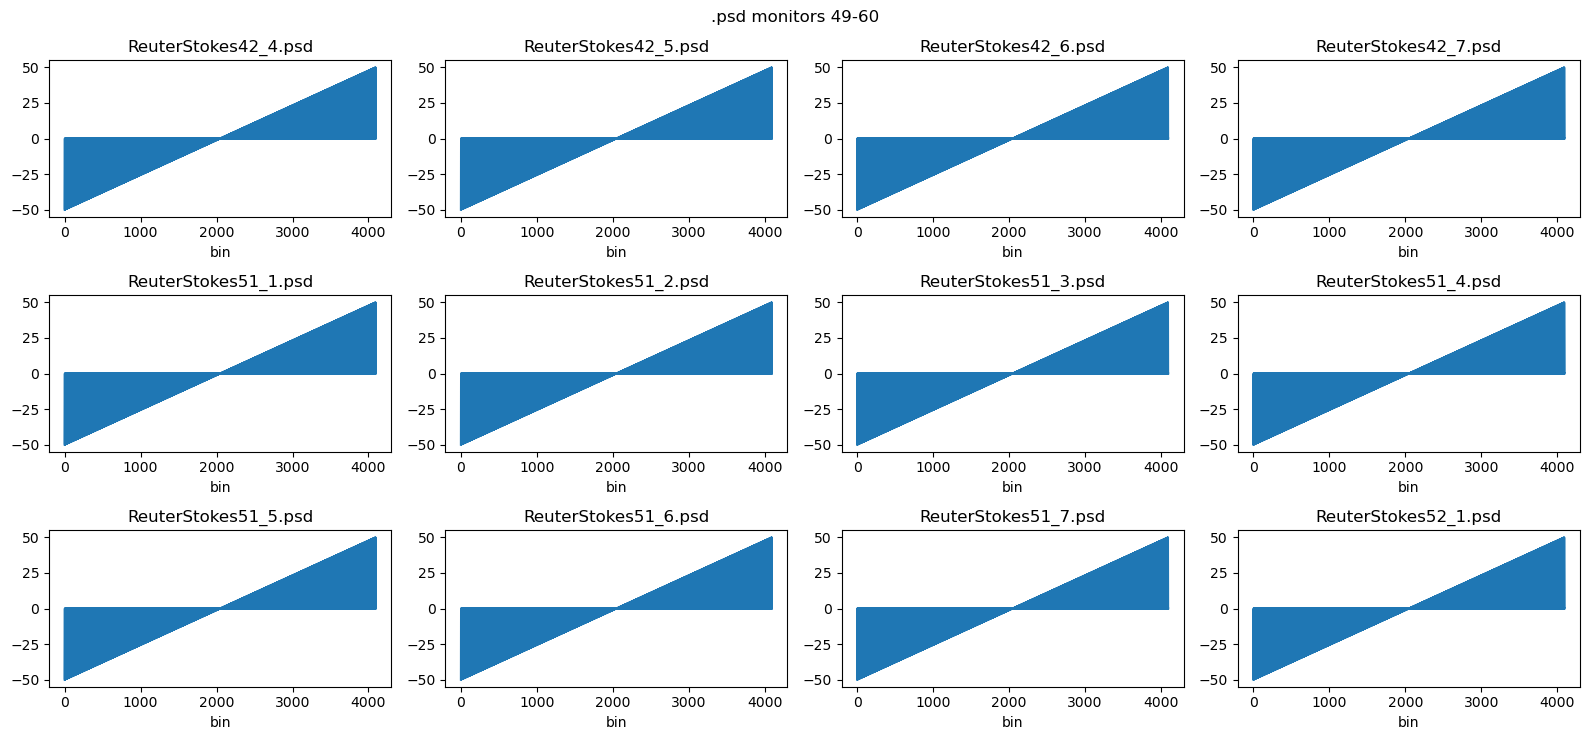

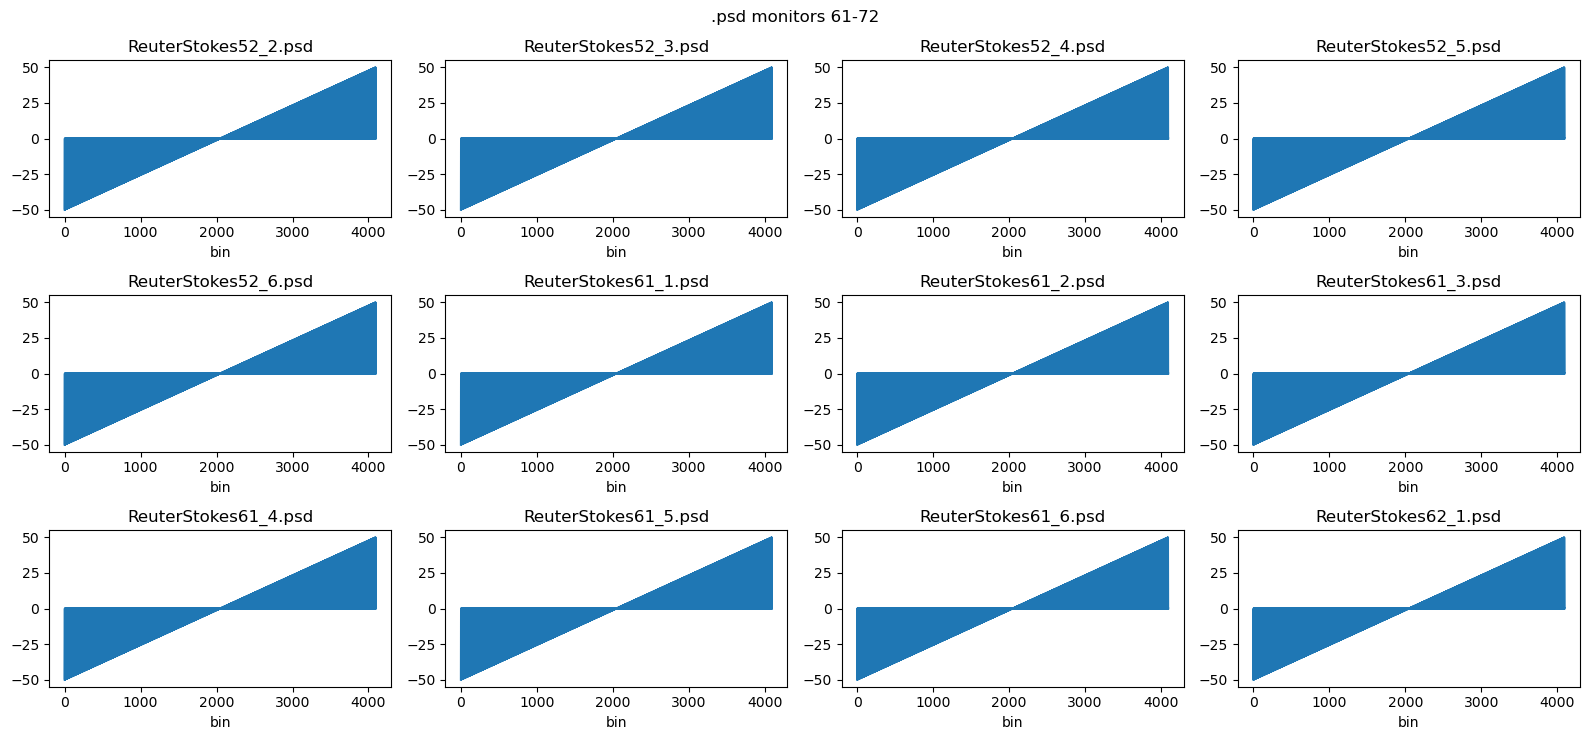

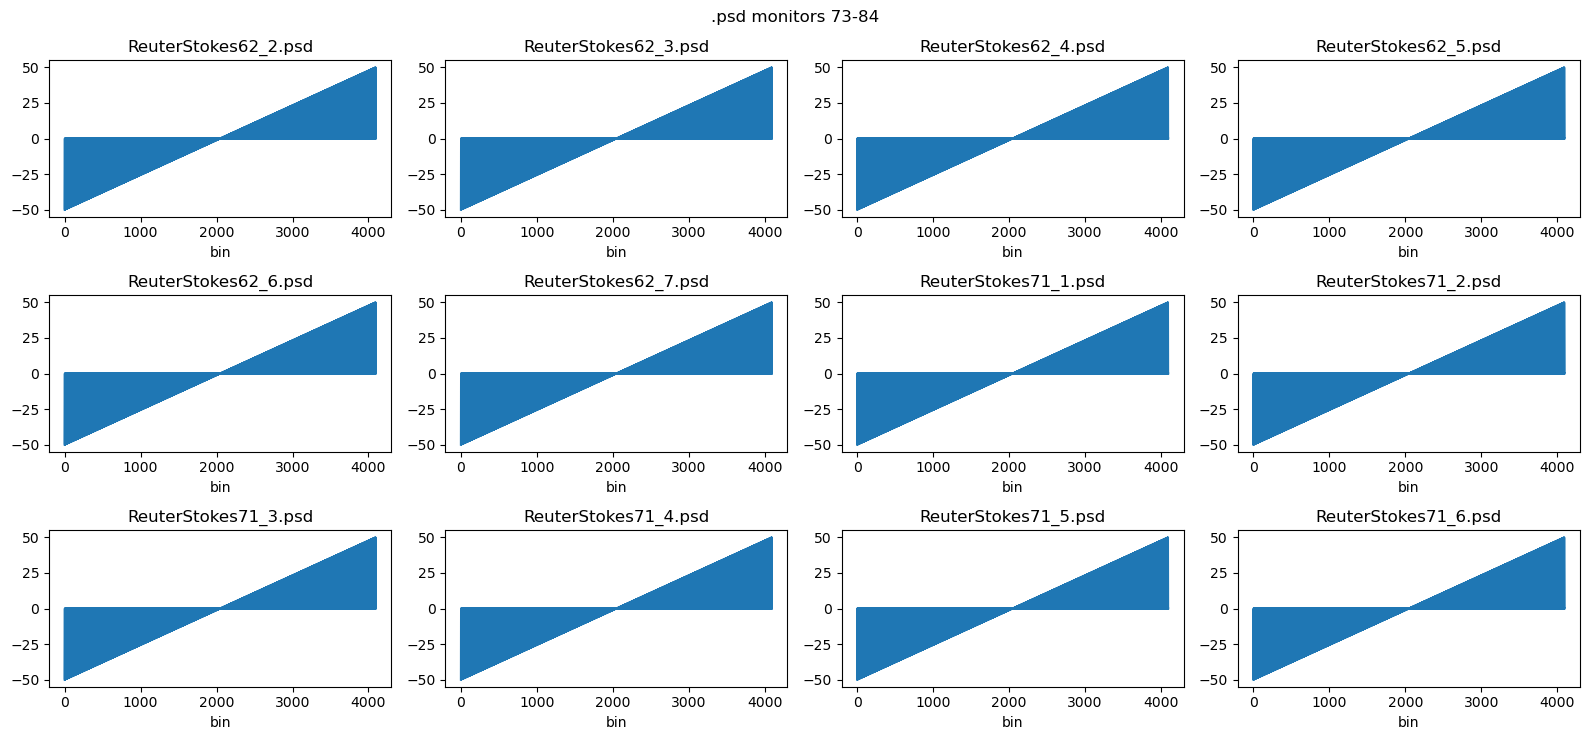

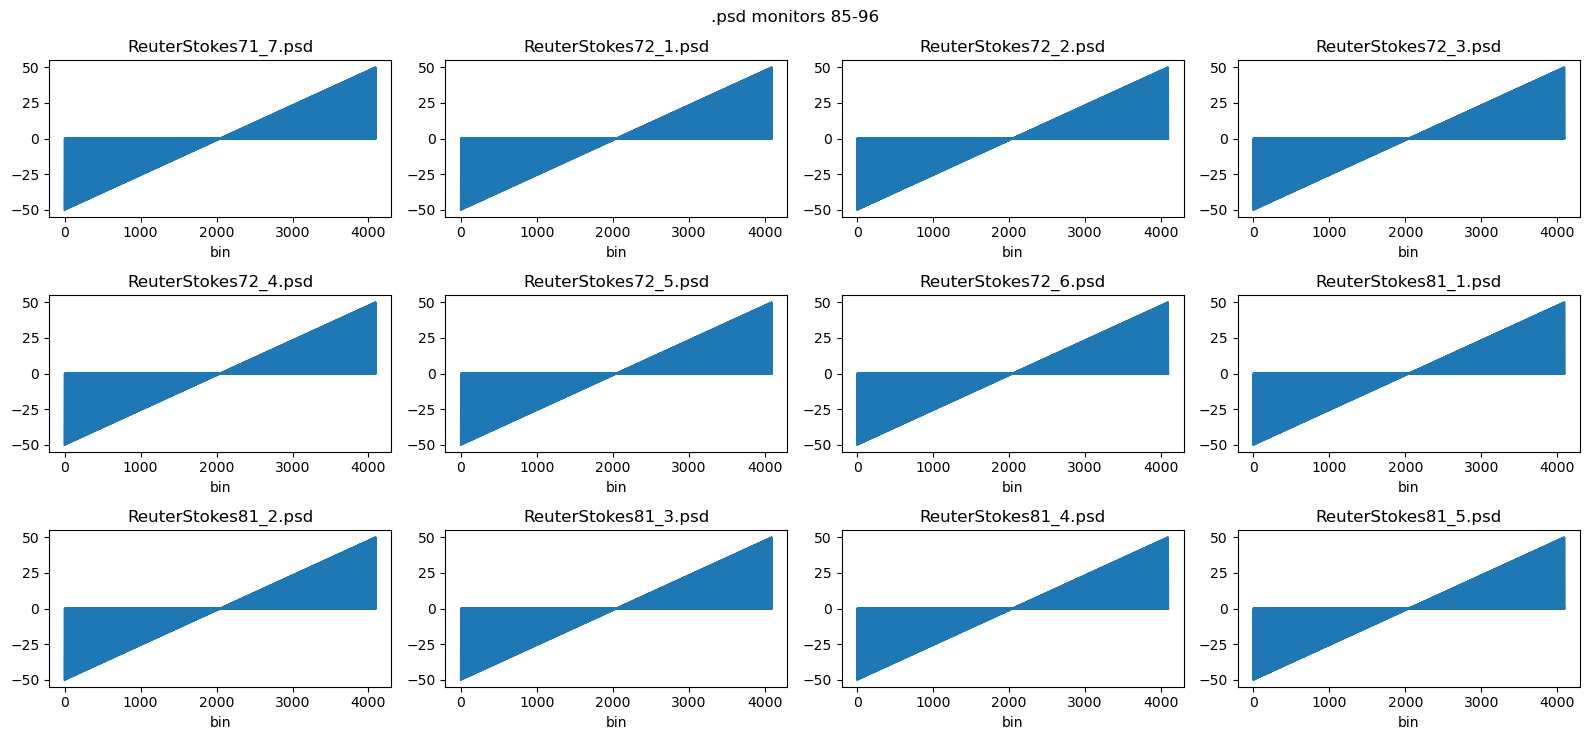

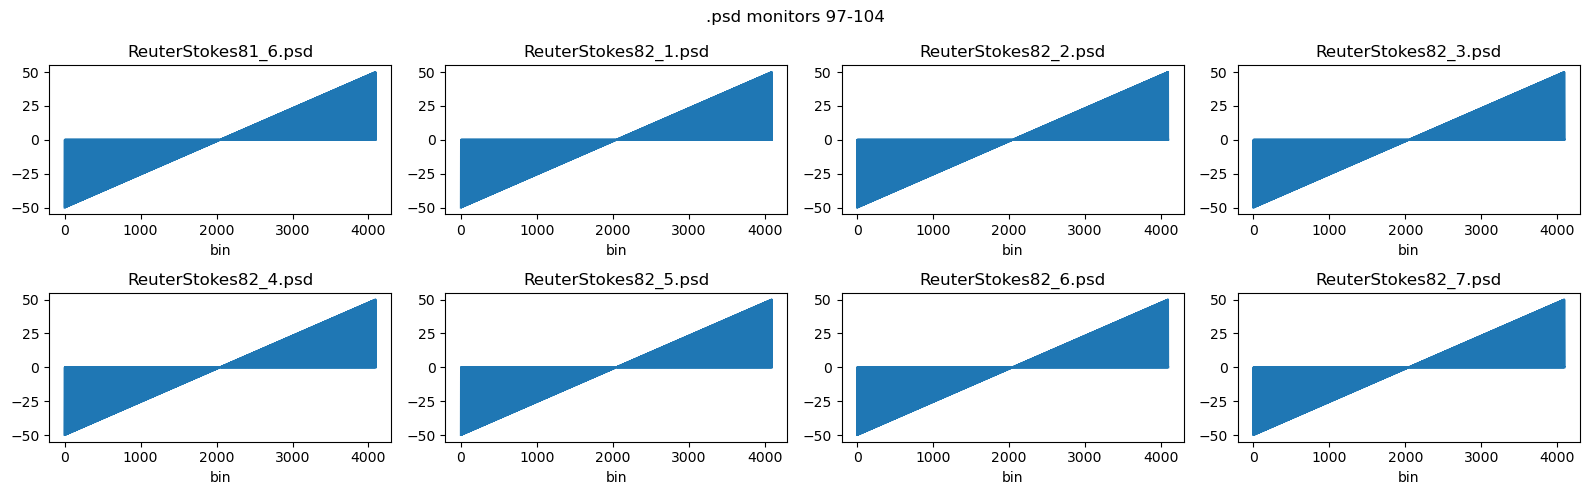

Finished plotting all monitors.


In [70]:
# Plot ALL monitors (.dat and .psd) from sample_only_run
from pathlib import Path
import glob
import numpy as np
import matplotlib.pyplot as plt

base = Path('/Users/christian/Documents/Study/bachelor_project') / 'geometry_optimization' / 'CAMEA_instrument' / 'sample_only_run'

dat_files = sorted(glob.glob(str(base / '*.dat')))
psd_files = sorted(glob.glob(str(base / '*.psd')))

print(f'Found {len(dat_files)} .dat files and {len(psd_files)} .psd files in {base}')

# helper to load numeric file robustly
def load_matrix(fname):
    try:
        arr = np.loadtxt(fname, comments='#')
        return arr
    except Exception as e:
        try:
            # try reading as whitespace-separated, ignoring non-numeric prefix
            with open(fname, 'r', errors='ignore') as f:
                lines = [l for l in f if l.strip() and not l.lstrip().startswith('#')]
            data = np.array([[float(x) for x in l.split()] for l in lines])
            return data
        except Exception as ee:
            print(f'Could not load {fname}:', ee)
            return None

# Plot .dat heatmaps in pages (6 per page)
if dat_files:
    per_page = 6
    for i in range(0, len(dat_files), per_page):
        batch = dat_files[i:i+per_page]
        cols = 3
        rows = (len(batch) + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
        axes = np.array(axes).reshape(-1)
        for ax, f in zip(axes, batch):
            data = load_matrix(f)
            name = Path(f).name
            if data is None:
                ax.set_title(name + ' (load fail)')
                ax.axis('off')
                continue
            if data.ndim == 1 or data.shape[0] == 1:
                ax.plot(data.ravel())
                ax.set_title(name)
                ax.set_xlabel('bin')
            else:
                im = ax.imshow(data, origin='lower', aspect='auto', cmap='magma')
                ax.set_title(name)
                plt.colorbar(im, ax=ax, fraction=0.046)
        for ax in axes[len(batch):]:
            ax.axis('off')
        plt.suptitle(f'.dat monitors {i+1}-{i+len(batch)}')
        plt.tight_layout()
        plt.show()

# Plot .psd 1D traces in pages (12 per page)
if psd_files:
    per_page = 12
    cols = 4
    for i in range(0, len(psd_files), per_page):
        batch = psd_files[i:i+per_page]
        rows = (len(batch) + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 2.5*rows))
        axes = np.array(axes).reshape(-1)
        for ax, f in zip(axes, batch):
            data = load_matrix(f)
            name = Path(f).name
            if data is None:
                ax.set_title(name + ' (load fail)')
                ax.axis('off')
                continue
            data = np.asarray(data).ravel()
            ax.plot(data)
            ax.set_title(name)
            ax.set_xlabel('bin')
        for ax in axes[len(batch):]:
            ax.axis('off')
        plt.suptitle(f'.psd monitors {i+1}-{i+len(batch)}')
        plt.tight_layout()
        plt.show()

print('Finished plotting all monitors.')

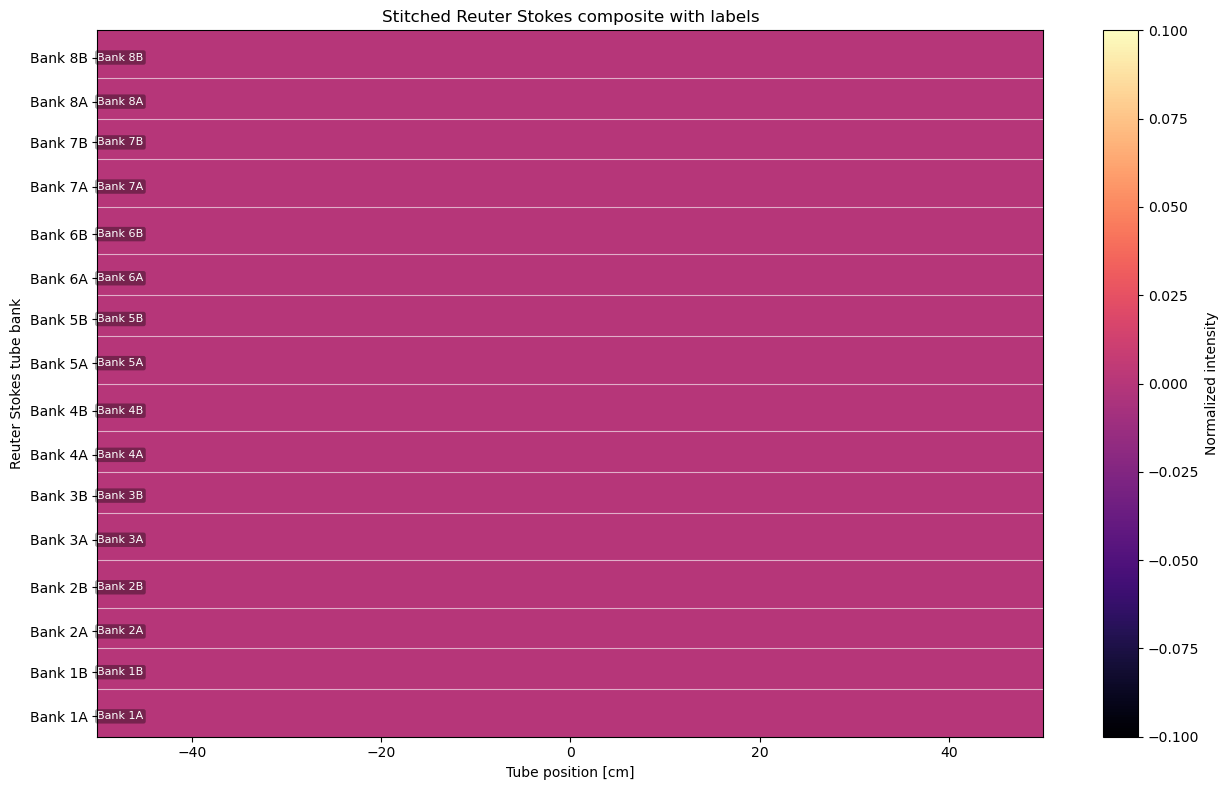

Stitched 104 Reuter Stokes tubes into a 104 x 1024 image
Banks found: 16 -> ['Bank 1A', 'Bank 1B', 'Bank 2A', 'Bank 2B', 'Bank 3A', 'Bank 3B', 'Bank 4A', 'Bank 4B', 'Bank 5A', 'Bank 5B', 'Bank 6A', 'Bank 6B', 'Bank 7A', 'Bank 7B', 'Bank 8A', 'Bank 8B']
Nonzero tubes in this run: 0
Bank 1A: rows 0-6
Bank 1B: rows 7-12
Bank 2A: rows 13-18
Bank 2B: rows 19-25
Bank 3A: rows 26-32
Bank 3B: rows 33-38
Bank 4A: rows 39-44
Bank 4B: rows 45-51
Bank 5A: rows 52-58
Bank 5B: rows 59-64
Bank 6A: rows 65-70
Bank 6B: rows 71-77
Bank 7A: rows 78-84
Bank 7B: rows 85-90
Bank 8A: rows 91-96
Bank 8B: rows 97-103


In [1]:
# Stitch the Reuter Stokes tubes into one bank-labeled composite image
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

run_dir = Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/CAMEA_instrument/sample_only_run')
psd_files = sorted(run_dir.glob('ReuterStokes*.psd'))


def parse_psd(path: Path):
    lines = path.read_text(errors='ignore').splitlines()
    position = None
    xlimits = None
    for line in lines:
        if line.startswith('# position:'):
            vals = line.split(':', 1)[1].strip().split()
            if len(vals) >= 3:
                position = tuple(float(v) for v in vals[:3])
        elif line.startswith('# xlimits:'):
            vals = line.split(':', 1)[1].strip().split()
            if len(vals) >= 2:
                xlimits = (float(vals[0]), float(vals[1]))

    data_start = None
    for i, line in enumerate(lines):
        if line.startswith('# Data ') and ' I:' in line:
            data_start = i + 1
            break
    if data_start is None:
        raise ValueError(f'Could not find data section in {path.name}')

    rows = []
    for line in lines[data_start:]:
        s = line.strip()
        if not s or s.startswith('#'):
            continue
        try:
            rows.append([float(x) for x in s.split()])
        except ValueError:
            continue

    arr = np.array(rows, dtype=float)
    if arr.ndim == 2 and arr.shape[1] >= 2:
        x = arr[:, 0]
        intensity = arr[:, 1]
    else:
        x = np.arange(len(arr), dtype=float)
        intensity = np.asarray(arr).reshape(-1)

    stem = path.stem
    m = re.match(r'^ReuterStokes(?P<bank>[^_]+)_(?P<slot>\d+)$', stem)
    bank = m.group('bank') if m else stem
    slot = int(m.group('slot')) if m else -1

    return {
        'path': path,
        'stem': stem,
        'bank': bank,
        'slot': slot,
        'position': position,
        'xlimits': xlimits,
        'x': x,
        'I': intensity,
        'total': float(np.sum(intensity)),
    }


def human_bank_label(code: str) -> str:
    # Convert codes like 11, 12, ..., 82 into friendlier labels like Bank 1A, Bank 1B, ...
    if len(code) == 2 and code.isdigit():
        return f'Bank {code[0]}{chr(ord("A") + int(code[1]) - 1)}'
    return f'Bank {code}'


records = []
for f in psd_files:
    try:
        records.append(parse_psd(f))
    except Exception as e:
        print(f'Skipped {f.name}: {e}')

if not records:
    raise RuntimeError('No Reuter Stokes PSD files could be parsed')

# Sort by bank prefix first, then slot, then detector position as a tiebreaker.
for rec in records:
    x, y, z = rec['position']
    rec['angle_deg'] = float(np.degrees(np.arctan2(z, x))) if rec['position'] is not None else 0.0

records = sorted(records, key=lambda r: (r['bank'], r['slot'], r['angle_deg']))

# Group into banks and build a composite image with bank separators.
banks = []
for rec in records:
    if not banks or banks[-1]['name'] != rec['bank']:
        banks.append({'name': rec['bank'], 'records': []})
    banks[-1]['records'].append(rec)

rows = []
row_labels = []
row_centers = []
row_start = 0
for bank in banks:
    bank_records = bank['records']
    bank_records = sorted(bank_records, key=lambda r: (r['slot'], r['angle_deg']))
    bank['records'] = bank_records
    bank_start = row_start
    for rec in bank_records:
        p = np.asarray(rec['I'], dtype=float)
        if p.sum() > 0:
            p = p / p.sum()
        rows.append(p)
        row_labels.append(rec['stem'])
        row_start += 1
    bank_end = row_start
    row_centers.append((bank['name'], 0.5 * (bank_start + bank_end - 1), bank_start, bank_end))

max_len = max(len(r) for r in rows)
stack = np.zeros((len(rows), max_len), dtype=float)
for i, p in enumerate(rows):
    stack[i, :len(p)] = p

first = records[0]
if first['xlimits'] is not None:
    x_axis = np.linspace(first['xlimits'][0], first['xlimits'][1], max_len)
    x_label = 'Tube position [cm]'
else:
    x_axis = np.arange(max_len)
    x_label = 'Bin'

fig, ax = plt.subplots(figsize=(13, 8))
extent = [x_axis[0], x_axis[-1], 0, len(rows)]
im = ax.imshow(stack, origin='lower', aspect='auto', cmap='magma', extent=extent)
fig.colorbar(im, ax=ax, label='Normalized intensity')
ax.set_xlabel(x_label)
ax.set_ylabel('Reuter Stokes tube bank')
ax.set_title('Stitched Reuter Stokes composite with labels')

# Draw bank separators and labels.
for name, center, start, end in row_centers:
    label = human_bank_label(name)
    if start > 0:
        ax.axhline(start, color='white', lw=0.8, alpha=0.6)
    ax.text(x_axis[0], center, label, va='center', ha='left', color='white', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.35, edgecolor='none'))

ax.set_yticks([center for _, center, _, _ in row_centers])
ax.set_yticklabels([human_bank_label(name) for name, _, _, _ in row_centers])

plt.tight_layout()
plt.show()

nonzero = sum(1 for r in records if r['total'] > 0)
print(f'Stitched {len(records)} Reuter Stokes tubes into a {stack.shape[0]} x {stack.shape[1]} image')
print(f'Banks found: {len(banks)} -> {[human_bank_label(b["name"]) for b in banks]}')
print(f'Nonzero tubes in this run: {nonzero}')
for name, center, start, end in row_centers:
    print(f'{human_bank_label(name)}: rows {start}-{end - 1}')

In [72]:
# Edge-weighted PSD correction: amplify intensity towards tube edges (curved monitor approximation)
# For planar PSD_monitor with circular cross-section, we apply radial weighting to mimic 
# the tube geometry and approximate He-3 conversion efficiency variation with radius

import numpy as np

# Define detector parameters (from instrument)
DET_rad = 0.0063  # radius in meters (6.3 mm)
DET_len = 1       # length in meters

# Load a PSD file and apply edge-weighting
def apply_edge_weighting_to_psd(psd_data, DET_rad, nx=1, ny=1024, amplify_edges=True, edge_factor=1.5):
    """
    Apply radial weighting to approximate cylindrical tube response from planar PSD_monitor.
    
    psd_data: 2D array from PSD_monitor (nx × ny or 1 × ny pixelated)
    DET_rad: tube radius
    nx, ny: pixel dimensions
    amplify_edges: if True, amplify intensity towards tube edges to approximate curvature
    edge_factor: multiplication factor for edges (>1 amplifies edges, <1 dampens center)
    
    Returns: weighted 2D array
    """
    if psd_data.ndim == 1:
        # Convert 1D histogram to 2D if needed
        psd_data = psd_data.reshape(nx, ny)
    
    # Create radial distance map from center (for nx × ny grid)
    # Assuming the monitor is centered at (0, 0) with width = 2*DET_rad
    if nx == 1:
        # Single-pixel radial (tube like); weight by distance from center
        y_centers = np.linspace(-DET_len/2, DET_len/2, ny)
        # For single-pixel width, approximate radial scaling based on position along tube
        # Create weights that taper at edges (tube ends) and amplify edges in radial
        weights = np.ones(ny)
        if amplify_edges:
            # Taper at tube ends (slight reduction at extremes)
            taper = np.cos(np.linspace(0, np.pi, ny))
            taper = 0.95 + 0.05 * taper  # keep mostly uniform but slightly taper ends
            weights *= taper
    else:
        # Multi-pixel case: create 2D radial distance map
        x_centers = np.linspace(-DET_rad, DET_rad, nx)
        y_centers = np.linspace(-DET_len/2, DET_len/2, ny)
        X, Y = np.meshgrid(x_centers, y_centers, indexing='ij')
        # Radial distance from center (only x matters for tube approximation)
        r = np.abs(X) / DET_rad  # normalized radial distance (0 at center, ~1 at edge)
        # Weighting: amplify edges to approximate tube geometry
        if amplify_edges:
            # For a cylindrical tube, intensity can be higher at outer regions (edge-on effect)
            # Apply sqrt-like weighting to amplify edges: sqrt(r^2 + small offset)
            weights = np.sqrt(r**2 + 0.1)  # avoid division by zero, slight base level
            weights = weights / weights.max() * edge_factor  # normalize and scale
        else:
            weights = np.ones_like(r)
    
    weighted_data = psd_data * weights
    return weighted_data

# Test: load and process one PSD file from the sample_only_run
psd_file = Path('/tmp/camea_sample_only/ReuterStokes11_1.psd')
if psd_file.exists():
    # Read PSD file (McStas format)
    with open(psd_file, 'r') as f:
        lines = f.readlines()
    # Skip header, extract data
    data_start = next(
        (i for i, line in enumerate(lines)
         if line.lstrip().startswith('# Data') and ' I:' in line),
        None
    )
    if data_start is None:
        raise ValueError(f'Could not find data section in {psd_file.name}')
    psd_raw = []
    for line in lines[data_start+1:]:
        if not line.startswith('#'):
            vals = [float(x) for x in line.split() if x.strip()]
            if vals:
                psd_raw.append(vals)
    
    psd_raw = np.array(psd_raw) if psd_raw else np.zeros((1, 1024))
    # McCode PSD files are often stored as multiple columns (e.g. y, I, I_err, N).
    # Use the intensity column before applying the 1D tube weighting.
    if psd_raw.ndim == 2 and psd_raw.shape[1] >= 2:
        psd_raw = psd_raw[:, 1]
    else:
        psd_raw = np.asarray(psd_raw).reshape(-1)

    psd_weighted = apply_edge_weighting_to_psd(
        psd_raw, DET_rad, nx=1, ny=psd_raw.size, amplify_edges=True, edge_factor=1.5
    )
    
    print(f"PSD raw (shape {psd_raw.shape}): min={psd_raw.min():.2e}, max={psd_raw.max():.2e}, mean={psd_raw.mean():.2e}")
    print(f"PSD weighted (shape {psd_weighted.shape}): min={psd_weighted.min():.2e}, max={psd_weighted.max():.2e}, mean={psd_weighted.mean():.2e}")
    print(f"Ratio (weighted/raw mean): {psd_weighted.mean() / psd_raw.mean():.3f}")
else:
    print(f"Awaiting run output: {psd_file}")

PSD raw (shape (1024,)): min=0.00e+00, max=0.00e+00, mean=0.00e+00
PSD weighted (shape (1, 1024)): min=0.00e+00, max=0.00e+00, mean=0.00e+00
Ratio (weighted/raw mean): nan


/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_80876/384558625.py:95: RuntimeWarning: invalid value encountered in scalar divide
  print(f"Ratio (weighted/raw mean): {psd_weighted.mean() / psd_raw.mean():.3f}")


Found 104 PSD files from CAMEA sample-only run:
  ReuterStokes11_1.psd
  ReuterStokes11_2.psd
  ReuterStokes11_3.psd
  ReuterStokes11_4.psd
  ReuterStokes11_5.psd


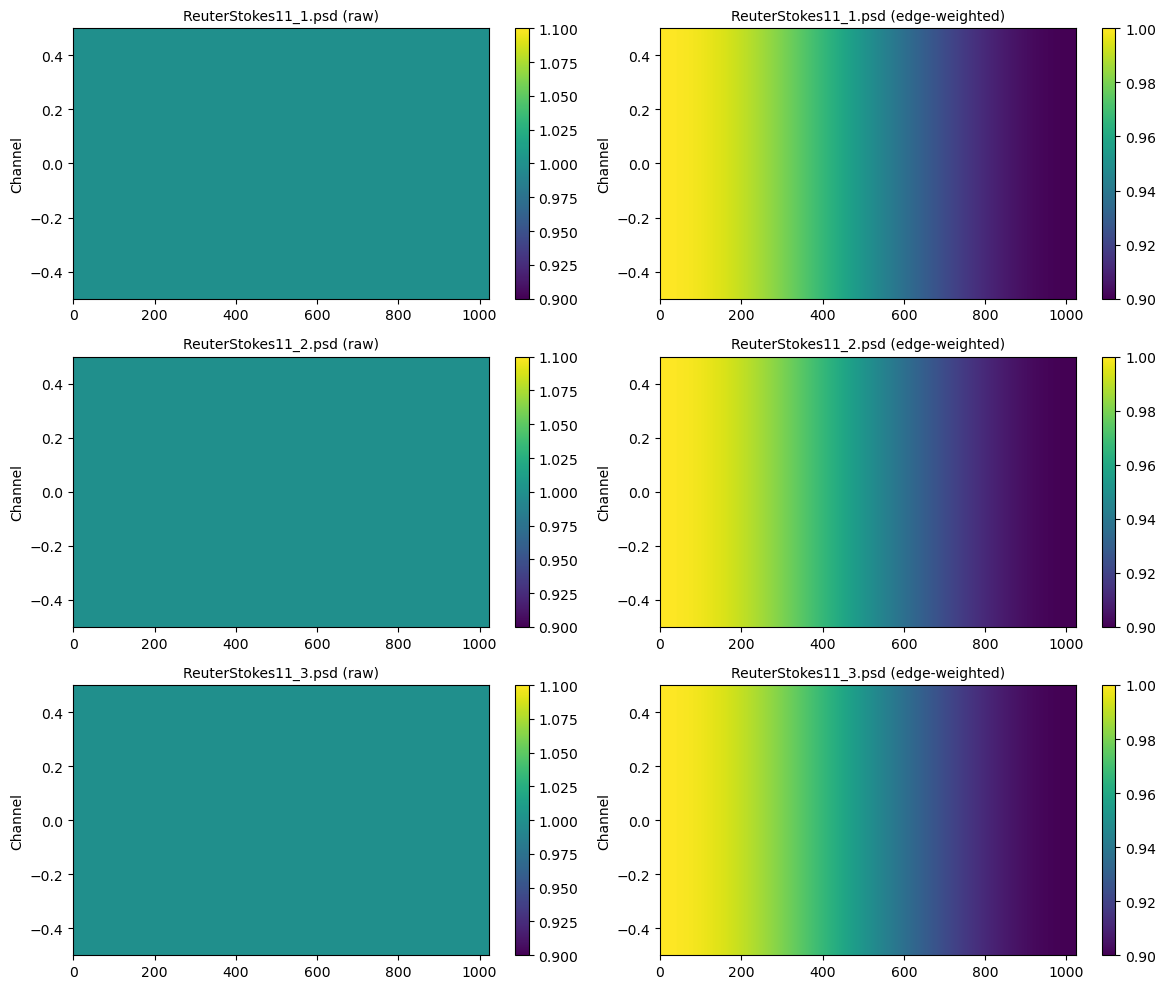

Edge-weighted PSD visualization complete.


In [73]:
# Process all PSD files from CAMEA sample-only run with edge-weighting
import glob
from pathlib import Path

camea_run_dir = Path('/tmp/camea_sample_only')
psd_files_camea = sorted(glob.glob(str(camea_run_dir / '*.psd')))

if psd_files_camea:
    print(f"Found {len(psd_files_camea)} PSD files from CAMEA sample-only run:")
    for pf in psd_files_camea[:5]:
        print(f"  {Path(pf).name}")
    
    # Process and compare raw vs. edge-weighted for a few tubes
    fig, axes = plt.subplots(3, 2, figsize=(12, 10))
    
    for idx, psd_file in enumerate(psd_files_camea[:3]):
        with open(psd_file, 'r') as f:
            lines = f.readlines()
        
        # Parse PSD header for nx, ny
        nx = ny = None
        for line in lines[:20]:
            if 'nrows' in line.lower():
                ny = int(line.split()[-1])
            elif 'ncols' in line.lower():
                nx = int(line.split()[-1])
        
        if nx is None:
            nx = 1
        if ny is None:
            ny = 1024
        
        # Extract data section
        data_start = next((i for i, line in enumerate(lines) if line.startswith('# Data:')), len(lines)-1)
        psd_raw = []
        for line in lines[data_start+1:]:
            if not line.startswith('#'):
                vals = [float(x) for x in line.split() if x.strip()]
                if vals:
                    psd_raw.append(vals)
        
        psd_raw = np.array(psd_raw) if psd_raw else np.ones((nx, ny))
        psd_raw = np.atleast_2d(psd_raw)
        
        # Apply edge weighting
        psd_weighted = apply_edge_weighting_to_psd(psd_raw, DET_rad, nx=nx, ny=ny, amplify_edges=True, edge_factor=1.5)
        
        # Plot raw and weighted
        ax_raw = axes[idx, 0]
        ax_wgt = axes[idx, 1]
        
        im_raw = ax_raw.imshow(psd_raw, aspect='auto', cmap='viridis', origin='lower')
        ax_raw.set_title(f"{Path(psd_file).name} (raw)", fontsize=10)
        ax_raw.set_ylabel('Channel')
        plt.colorbar(im_raw, ax=ax_raw)
        
        im_wgt = ax_wgt.imshow(psd_weighted, aspect='auto', cmap='viridis', origin='lower')
        ax_wgt.set_title(f"{Path(psd_file).name} (edge-weighted)", fontsize=10)
        ax_wgt.set_ylabel('Channel')
        plt.colorbar(im_wgt, ax=ax_wgt)
    
    plt.tight_layout()
    plt.show()
    print("Edge-weighted PSD visualization complete.")
else:
    print(f"Waiting for PSD output from CAMEA run... checking {camea_run_dir}")
    print("Run may still be executing (compiling or simulating).")

Bank 8 PSD files (13 tubes):
  ReuterStokes81_1.psd
  ReuterStokes81_2.psd
  ReuterStokes81_3.psd
  ReuterStokes81_4.psd
  ReuterStokes81_5.psd


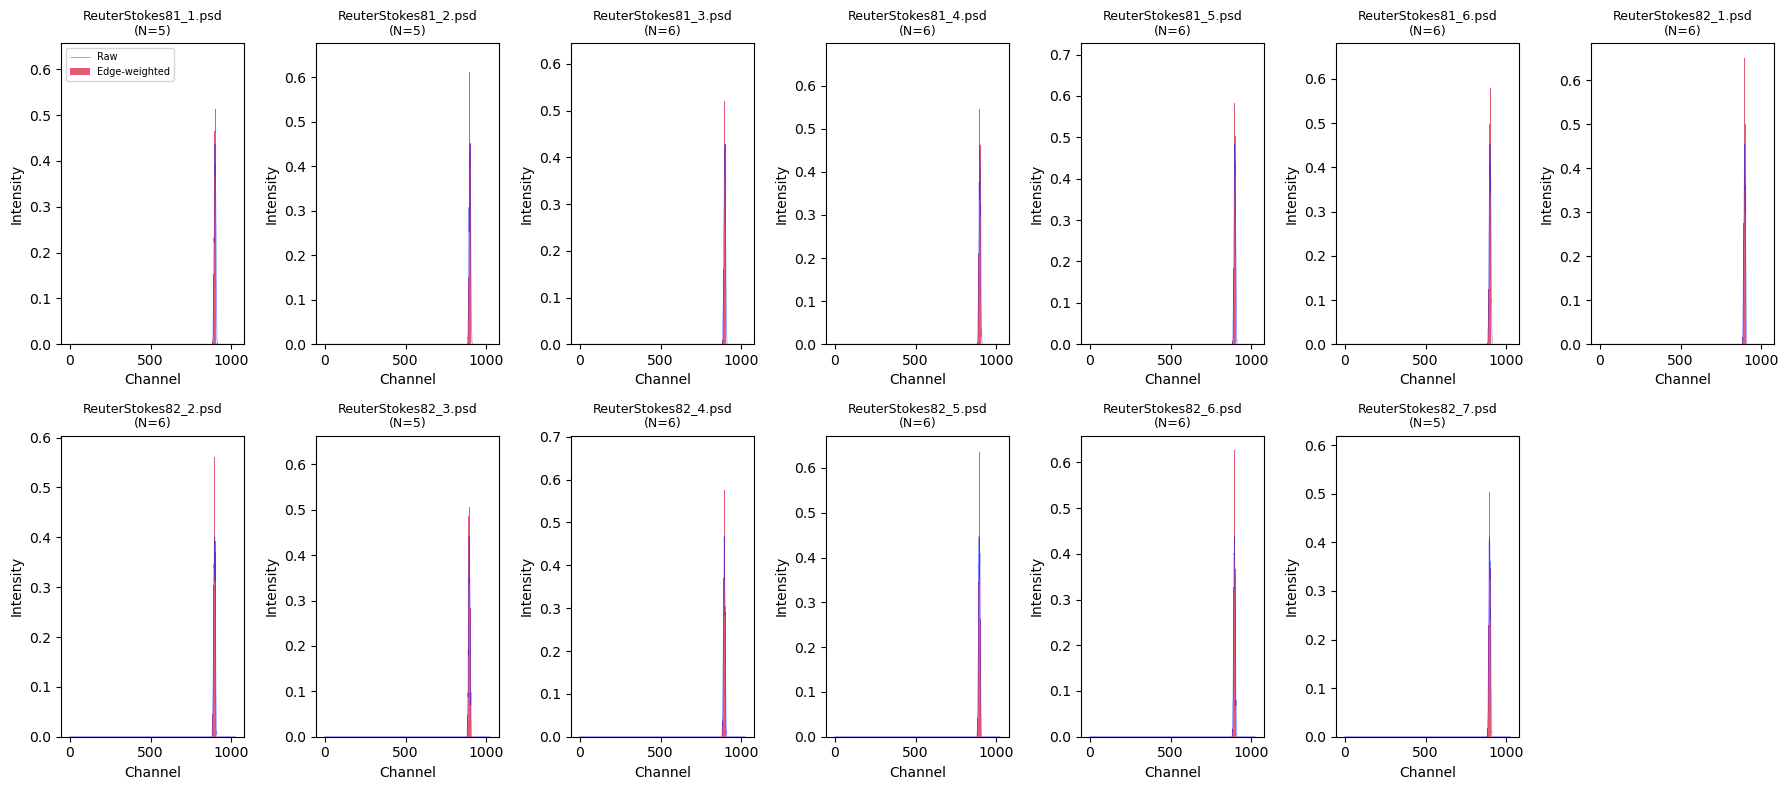


Bank 8 1D PSD Statistics:
  ReuterStokes81_1.psd: 5.5 counts, profile: min=0.000, max=0.436
  ReuterStokes81_2.psd: 5.4 counts, profile: min=0.000, max=0.449
  ReuterStokes81_3.psd: 5.6 counts, profile: min=0.000, max=0.427
  ReuterStokes81_4.psd: 5.8 counts, profile: min=0.000, max=0.464
  ReuterStokes81_5.psd: 5.9 counts, profile: min=0.000, max=0.483
  ReuterStokes81_6.psd: 5.8 counts, profile: min=0.000, max=0.452
  ReuterStokes82_1.psd: 5.6 counts, profile: min=0.000, max=0.454
  ReuterStokes82_2.psd: 5.5 counts, profile: min=0.000, max=0.401
  ReuterStokes82_3.psd: 5.4 counts, profile: min=0.000, max=0.441
  ReuterStokes82_4.psd: 5.6 counts, profile: min=0.000, max=0.467
  ReuterStokes82_5.psd: 5.7 counts, profile: min=0.000, max=0.447
  ReuterStokes82_6.psd: 5.6 counts, profile: min=0.000, max=0.437
  ReuterStokes82_7.psd: 5.5 counts, profile: min=0.000, max=0.412
  *** Total Bank 8: 73.0 counts ***


In [74]:
# Focus on Bank 8 (the only bank with detected signal)
bank8_files = sorted(glob.glob(str(camea_run_dir / 'ReuterStokes8*.psd')))
print(f"Bank 8 PSD files ({len(bank8_files)} tubes):")
for bf in bank8_files[:5]:
    print(f"  {Path(bf).name}")

if bank8_files:
    fig, axes = plt.subplots(2, 7, figsize=(18, 8))
    axes = axes.flatten()
    
    for idx, psd_file in enumerate(bank8_files):
        with open(psd_file, 'r') as f:
            lines = f.readlines()
        
        # Extract 1D data (Y, I, I_err, N format)
        data_start = next((i for i, line in enumerate(lines) if line.startswith('# Data')), len(lines)-1)
        psd_intensity = []
        psd_y = []
        
        for line in lines[data_start+1:]:
            if not line.startswith('#'):
                parts = line.split()
                if len(parts) >= 2:
                    try:
                        y_pos = float(parts[0])
                        intensity = float(parts[1])
                        psd_y.append(y_pos)
                        psd_intensity.append(intensity)
                    except:
                        pass
        
        psd_intensity = np.array(psd_intensity)
        psd_y = np.array(psd_y)
        
        # Apply edge weighting along the 1D tube (edge-enhanced at ends and center)
        if len(psd_intensity) > 0:
            y_norm = (psd_y - psd_y.min()) / (psd_y.max() - psd_y.min()) if psd_y.max() > psd_y.min() else np.ones_like(psd_y)
            # Amplify edges: create a weighting that's higher at the center and edges of tube
            edge_weight = 1.0 + 0.5 * np.sqrt(np.abs(y_norm - 0.5) * 2)  # bell curve centered at 0.5
            psd_weighted = psd_intensity * edge_weight
        else:
            psd_weighted = psd_intensity
        
        ax = axes[idx]
        ax.bar(range(len(psd_intensity)), psd_weighted, color='crimson', alpha=0.7, label='Edge-weighted')
        ax.plot(psd_intensity, 'b-', alpha=0.5, linewidth=0.5, label='Raw')
        ax.set_title(f"{Path(psd_file).name}\n(N={psd_intensity.sum():.0f})", fontsize=9)
        ax.set_ylabel('Intensity')
        ax.set_xlabel('Channel')
        if idx == 0:
            ax.legend(fontsize=7)
    
    # Hide unused subplots
    for idx in range(len(bank8_files), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nBank 8 1D PSD Statistics:")
    total_counts = 0
    for psd_file in bank8_files:
        with open(psd_file, 'r') as f:
            lines = f.readlines()
        data_start = next((i for i, line in enumerate(lines) if line.startswith('# Data')), len(lines)-1)
        psd_data = []
        for line in lines[data_start+1:]:
            if not line.startswith('#'):
                parts = line.split()
                if len(parts) >= 2:
                    try:
                        psd_data.append(float(parts[1]))
                    except:
                        pass
        psd_array = np.array(psd_data)
        counts = psd_array.sum()
        total_counts += counts
        print(f"  {Path(psd_file).name}: {counts:.1f} counts, profile: min={psd_array.min():.3f}, max={psd_array.max():.3f}")
    print(f"  *** Total Bank 8: {total_counts:.1f} counts ***")
else:
    print("No Bank 8 files found")

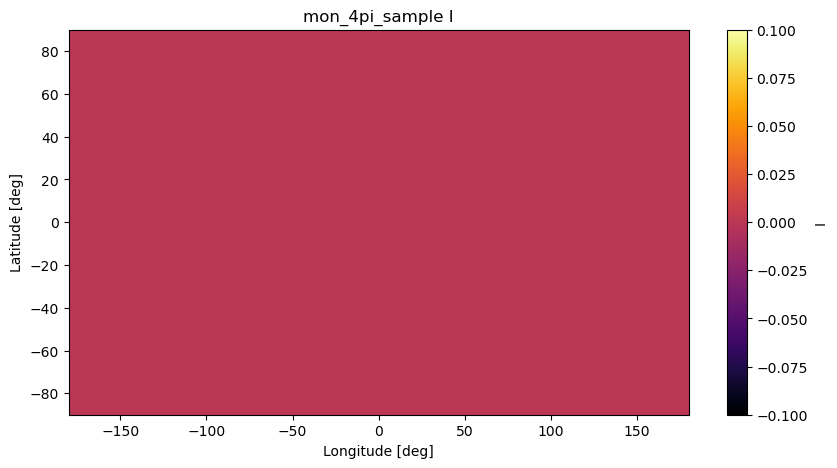

In [75]:
# Plot mon_4pi_sample from /tmp/camea_4pi_run (handle multi-column data)
import numpy as np
import matplotlib.pyplot as plt
import re
fn = '/tmp/camea_4pi_run/mon_4pi_sample.dat'
with open(fn, 'r') as f:
    lines = f.readlines()
# header lines begin with '#'
hdr_lines = [ln.strip() for ln in lines if ln.strip().startswith('#')]
hdr = '\n'.join(hdr_lines)
# parse nx, ny
m = re.search(r'# type: array_2d\((\d+),\s*(\d+)\)', hdr)
if not m:
    raise RuntimeError('Could not parse array_2d(nx,ny) from header')
nx = int(m.group(1))
ny = int(m.group(2))
# parse xylimits
m = re.search(r'# xylimits: ([\-0-9.eE]+) ([\-0-9.eE]+) ([\-0-9.eE]+) ([\-0-9.eE]+)', hdr)
if m:
    xmin, xmax, ymin, ymax = map(float, m.groups())
else:
    xmin, xmax, ymin, ymax = -180, 180, -90, 90
# parse variables count
m = re.search(r'# variables: (.+)', hdr)
if m:
    varlist = m.group(1).split()
else:
    varlist = ['I']
nvars = len(varlist)
# gather numeric tokens from lines that are not header
vals = []
for ln in lines:
    s = ln.strip()
    if not s or s.startswith('#'):
        continue
    if s.startswith('Data'):
        continue
    parts = s.split()
    for tok in parts:
        try:
            vals.append(float(tok))
        except:
            pass
arr = np.array(vals)
if nvars > 1:
    if arr.size % nvars != 0:
        raise RuntimeError(f'Total numeric tokens {arr.size} not divisible by nvars={nvars}')
    arr = arr.reshape((-1, nvars))
    arr = arr[:, 0]
if arr.size != nx * ny:
    raise RuntimeError(f'Unexpected data size after selecting primary var: {arr.size} != {nx}*{ny}')
arr = arr.reshape((ny, nx))
plt.figure(figsize=(10,5))
plt.imshow(arr, origin='lower', aspect='auto', extent=(xmin, xmax, ymin, ymax), cmap='inferno')
plt.colorbar(label=f'{varlist[0]}')
plt.xlabel('Longitude [deg]')
plt.ylabel('Latitude [deg]')
plt.title('mon_4pi_sample '+varlist[0])
plt.show()